# AMI — Combining Annual Reports + Job Postings

Compares the two evidence tracks (annual-report NLP scores and job-posting signal scores)
at **company** and **tier** levels, and analyzes **annual-report progression over time**.

**Design decisions (locked):**
- Annual reports represented by **the aggregated 3 years of reports** per company for the combine.
- Postings metric: **total signal density** (per-posting mean). 
- **Agentic-only** density using phrase detail.
- Each source **z-scored within itself** so they're comparable.
- Levels: **company** and **tier**. (Region dropped — group-level reports have no regional split.)
- Progression: **all companies, gaps flagged**.

**Reading the Results**
- **Company agreement:** the scatter (section 4) shows whether a company's annual-report story
  matches its hiring signal. Near-zero correlation means the two lenses capture *different*
  things — a finding, not a failure. Off-diagonal companies are the interesting cases.
- **Small n (~29):** correlations are exploratory. Report p-values but don't over-claim.
- **Role-evolution overlap:** both sources touch role-evolution, so correlation there is partly
  mechanical — weaker correlation elsewhere is the more informative signal.
- **Progression (reports only):** postings are a snapshot, so there's no postings time-series to
  compare against. Dashed lines / flagged companies have incomplete year coverage — their
  slopes rest on 1-2 points and shouldn't be read as trends.

### 0. Setup

In [1]:
import sys
for pkg in ["pandas","numpy","matplotlib","seaborn","scipy"]:
    try: __import__(pkg); print(f"  {pkg:12s} OK")
    except ImportError: print(f"  {pkg:12s} MISSING")


  pandas       OK
  numpy        OK
  matplotlib   OK
  seaborn      OK
  scipy        OK


In [2]:
%pip install pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import json

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
plt.rcParams["savefig.bbox"]="tight"; plt.rcParams["axes.titleweight"]="bold"
TIER_COLORS={"A": "#4d7298", "B": "#66ad76", "C": "#de73aa"}

# ---- paths: resolved relative to the repo, not to any one machine ----
def _find_repo_root():
    """Walk up from the working directory until the repo layout is found."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data").is_dir() and (cand / "notebooks").is_dir():
            return cand
    return here

ROOT    = _find_repo_root()
DATA    = ROOT / "data"
PROCESSED = ROOT / DATA / "processed"
FIG_DIR = ROOT / "figures" / "ami_combine_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

AR_PATH        = PROCESSED / "ami_results_wide.csv"
POST_PATH      = PROCESSED / "posting_level_detail.csv"
PHRASE_DETAIL  = PROCESSED / "phrase_detail.csv"
SENIORITY_PATH = PROCESSED / "job_postings_combined_cleaned.csv"

_missing = [p.name for p in (AR_PATH, POST_PATH, PHRASE_DETAIL, SENIORITY_PATH) if not p.exists()]
if _missing:
    raise FileNotFoundError(
        f"Missing from {DATA}: {_missing}\n"
        "See data/README.md for how to obtain or regenerate these files."
    )

def save(fig,name): fig.savefig(FIG_DIR/f"{name}.png"); print(f"  saved -> {name}.png")
def zscore(s): return (s-s.mean())/s.std(ddof=0) if s.std(ddof=0) else s*0
print(f"Setup done. Repo root: {ROOT}")

Setup done. Repo root: /Users/savannahwand/Library/CloudStorage/OneDrive-Personal/Documents/Bayes Term 3/GRP/github


### 1. Load both sources & check the join key
Do company names match between the two files?

In [4]:
ar = pd.read_csv(AR_PATH)
p  = pd.read_csv(POST_PATH)
print(f"Reports: {ar.shape}, {ar['company'].nunique()} companies, years {sorted(ar['year'].unique())}")
print(f"Postings: {p.shape}, {p['company'].nunique()} companies")

ar_co, p_co = set(ar['company'].unique()), set(p['company'].astype(str).unique())
both = sorted(ar_co & p_co)
print(f"\nIn BOTH ({len(both)}): {both}")
print(f"Only in reports: {sorted(ar_co - p_co)}")
print(f"Only in postings: {sorted(p_co - ar_co)}")
print("\n-> Combined analysis runs on the companies in BOTH.")


Reports: (86, 21), 29 companies, years [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Postings: (2984, 8), 29 companies

In BOTH (29): ['AXA', 'Admiral', 'Ageas', 'Allianz', 'Alm Brand Group', 'Aviva', 'Beazley', 'Bolttech', 'Coface', 'Generali', 'Gjensidige', 'Helvetia Baloise', 'Hiscox', 'Lemonade', 'Linea Directa Aseguradora', 'Mapfre', 'Marshmallow', 'Munich Re', 'NN Group', 'Neodigital', 'Sampo', 'Swiss Re', 'Talanx', 'Tryg', 'Unipol', 'VIG', 'Wakam', 'Zego', 'Zurich']
Only in reports: []
Only in postings: []

-> Combined analysis runs on the companies in BOTH.


### 2. Collapse each source to one value per company

In [5]:
# POSTINGS: total signal density (mean signals per posting) + volume
post = p.groupby("company").agg(
    n_postings=("signal_count","size"),
    post_density_total=("signal_count","mean"),
).reset_index()
post["post_density_total"] = post["post_density_total"].round(3)

# REPORTS: aggregate across ALL available years per company (sum raw hits, then take the
# ratio) -- NOT latest-year-only, and NOT an average of yearly ratios, since that would
# over-weight years with tiny/zero denominators (e.g. a company with 0/1 hits one year
# would count equally alongside a year with 20/40 hits under a naive average).
ar_agg = ar.groupby("company", as_index=False).agg(
    tier=("tier","first"),
    n_years=("year","nunique"),
    years_used=("year", lambda s: sorted(s.unique().tolist())),
    tokens_total=("tokens","sum"),
    raw_agentic=("raw_agentic","sum"),
    raw_prior_gen_automation=("raw_prior_gen_automation","sum"),
)
ar_agg["total_automation_hits"] = ar_agg["raw_agentic"] + ar_agg["raw_prior_gen_automation"]
ar_agg["agentic_share_of_automation"] = (
    ar_agg["raw_agentic"] / ar_agg["total_automation_hits"].replace(0, np.nan)
).fillna(0)  # true 0/0 (no automation-dimension language detected at all) stays 0, not NaN

# the 3 per-10k dimension rates aren't raw counts in this file, so aggregate them as a
# token-weighted average across years (mathematically equal to summing the underlying
# raw hits and dividing by summed tokens, since rate_i = raw_i / tokens_i * 10000)
def token_weighted_mean(df_year, col):
    w = df_year["tokens"]
    return (df_year[col] * w).sum() / w.sum() if w.sum() else 0.0

dim_agg = ar.groupby("company").apply(
    lambda g: pd.Series({
        "dim_role_evolution_per10k": token_weighted_mean(g, "dim_role_evolution_per10k"),
        "dim_tech_stack_per10k":     token_weighted_mean(g, "dim_tech_stack_per10k"),
        "dim_governance_per10k":     token_weighted_mean(g, "dim_governance_per10k"),
    })
).reset_index()

ar_agg = ar_agg.merge(dim_agg, on="company", how="left")

ar_agg["rep_composite"] = (
    zscore(ar_agg["dim_role_evolution_per10k"])
  + zscore(ar_agg["dim_tech_stack_per10k"])
  + zscore(ar_agg["dim_governance_per10k"])
) / 3

rep_cols = ["company","tier","n_years","years_used","total_automation_hits",
            "agentic_share_of_automation","dim_role_evolution_per10k",
            "dim_tech_stack_per10k","dim_governance_per10k","rep_composite"]
rep = ar_agg[rep_cols].copy()
print("Reports (3-year aggregate) sample:")
print(rep.head().round(3).to_string(index=False))
print(f"\nCompanies with <3 years of report coverage (interpret cautiously): "
      f"{rep[rep['n_years']<3]['company'].tolist()}")


Reports (3-year aggregate) sample:
        company tier  n_years         years_used  total_automation_hits  agentic_share_of_automation  dim_role_evolution_per10k  dim_tech_stack_per10k  dim_governance_per10k  rep_composite
            AXA    A        3 [2023, 2024, 2025]                    175                        0.720                      2.589                  2.737                  3.728          0.875
        Admiral    B        3 [2023, 2024, 2025]                     78                        0.846                      1.283                  1.969                  1.601         -0.281
          Ageas    B        3 [2023, 2024, 2025]                    154                        0.662                      1.619                  2.638                  3.000          0.345
        Allianz    A        3 [2023, 2024, 2025]                     49                        0.755                      1.196                  4.888                  2.691          0.400
Alm Brand Group    C

### 3. Merge + standardize (the combined table)

In [6]:
m = rep.merge(post, on="company", how="inner")

# standardize within each source
m["z_report_share"]  = zscore(m["agentic_share_of_automation"])
m["z_report_comp"]   = zscore(m["rep_composite"])
m["z_postings_total"]= zscore(m["post_density_total"])

m = m.sort_values("z_report_share", ascending=False).reset_index(drop=True)
m.to_csv(FIG_DIR/"combined_company_scores.csv", index=False)
print(f"Combined table: {len(m)} companies")
m[["company","tier","agentic_share_of_automation","post_density_total",
   "z_report_share","z_postings_total","n_postings"]].round(2)


Combined table: 29 companies


,company,tier,agentic_share_of_automation,post_density_total,z_report_share,z_postings_total,n_postings
0,Zego,C,1.00,14.84,1.37,2.48,32
1,Marshmallow,C,1.00,10.15,1.37,1.26,13
2,Aviva,A,0.90,1.80,1.04,-0.90,25
3,Munich Re,A,0.90,3.88,1.04,-0.36,8
4,Zurich,A,0.86,2.88,0.91,-0.62,56
5,Admiral,B,0.85,7.29,0.86,0.52,31
6,Talanx,A,0.82,1.90,0.77,-0.87,160
7,Lemonade,C,0.80,10.00,0.71,1.22,4
8,Mapfre,A,0.79,2.22,0.66,-0.79,40
9,NN Group,A,0.77,10.14,0.62,1.26,62


### 3b. Agentic-only postings density

In [7]:
pd_det = pd.read_csv(PHRASE_DETAIL)

agentic = pd_det[pd_det["category"] == "agentic"].groupby("company")["count"].sum()
totals = p.groupby("company").size()

agentic_density = (agentic / totals).fillna(0).reset_index()
agentic_density.columns = ["company", "post_density_agentic"]

m = m.drop(columns=[c for c in ["post_density_agentic","z_postings_agentic"] if c in m.columns])

m = m.merge(agentic_density, on="company", how="left")
m["post_density_agentic"] = m["post_density_agentic"].fillna(0)
m["z_postings_agentic"] = zscore(m["post_density_agentic"])
print(f"Agentic-only density added for {len(m)} companies.")
print(m[["company", "post_density_total", "post_density_agentic",
         "z_postings_agentic"]].round(3).sort_values("post_density_agentic", ascending=False).to_string(index=False))

Agentic-only density added for 29 companies.
                  company  post_density_total  post_density_agentic  z_postings_agentic
                    Wakam              14.846                 3.231               3.069
Linea Directa Aseguradora               5.200                 2.800               2.550
               Gjensidige               7.235                 2.118               1.727
              Marshmallow              10.154                 1.769               1.307
                 NN Group              10.145                 1.274               0.710
                     Zego              14.844                 1.188               0.605
                 Generali               5.959                 1.045               0.433
                    Ageas               7.071                 0.857               0.207
                  Allianz               5.312                 0.769               0.101
                 Swiss Re               9.326                 0.732        

### 4. Company-level comparison — do the two sources agree?

In [8]:
rho, pval = stats.spearmanr(m["z_report_share"], m["z_postings_total"])
print(f"Spearman correlation (report agentic-share vs postings density): rho={rho:.3f}, p={pval:.3f}, n={len(m)}")

# robustness across report metrics
print("\nCorrelation of postings density vs each report metric:")
for label,col in [("agentic_share","agentic_share_of_automation"),
                  ("role_evolution","dim_role_evolution_per10k"),
                  ("tech_stack","dim_tech_stack_per10k"),
                  ("governance","dim_governance_per10k"),
                  ("composite","rep_composite")]:
    r,pv = stats.spearmanr(m[col], m["post_density_total"])
    print(f"  {label:16s} rho={r:+.3f}  p={pv:.3f}")


Spearman correlation (report agentic-share vs postings density): rho=0.148, p=0.443, n=29

Correlation of postings density vs each report metric:
  agentic_share    rho=+0.148  p=0.443
  role_evolution   rho=+0.259  p=0.174
  tech_stack       rho=-0.139  p=0.471
  governance       rho=-0.118  p=0.541
  composite        rho=+0.129  p=0.506


  saved -> 01_report_vs_postings_scatter.png


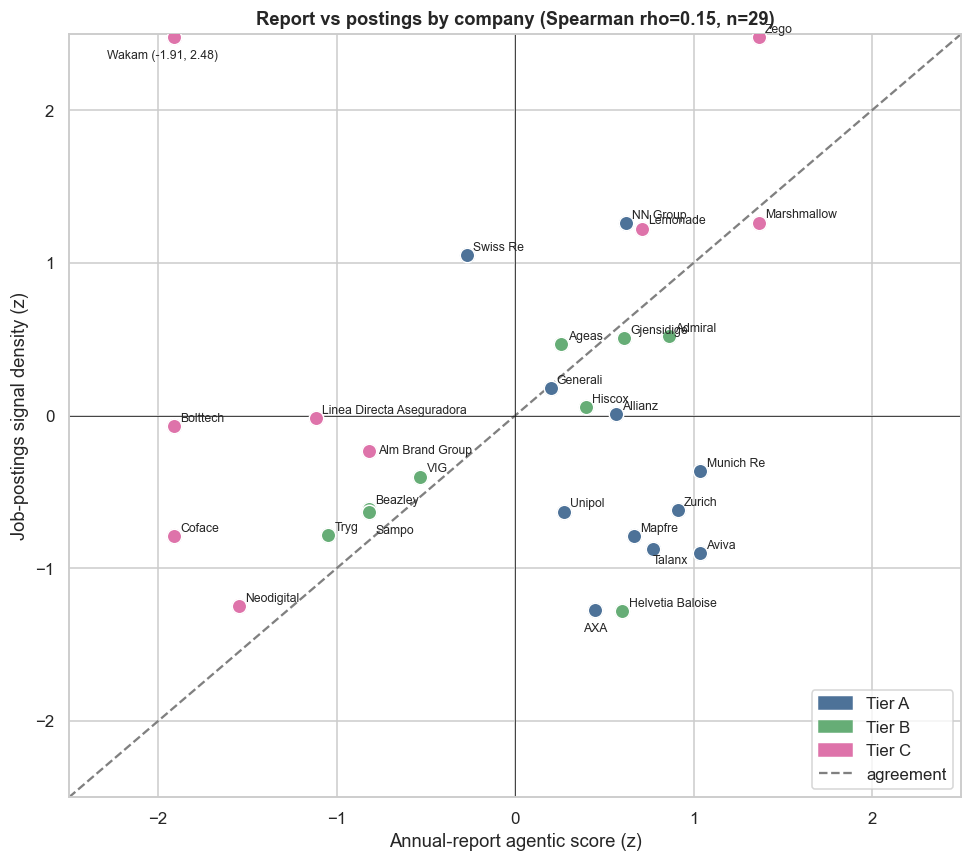

Off-diagonal = the two sources disagree for that company.
Upper-left: strong on postings, weak in report. Lower-right: strong in report, weak on postings.


In [9]:
# scatter: report-z (x) vs postings-z (y), diagonal = perfect agreement
fig, ax = plt.subplots(figsize=(9,8))
for _,r in m.iterrows():
    ax.scatter(r["z_report_share"], r["z_postings_total"], s=80,
               color=TIER_COLORS.get(r["tier"],"#888"), zorder=3)

lim=2.5
for _, r in m.iterrows():
    ax.scatter(r["z_report_share"], r["z_postings_total"], s=90,
               color=TIER_COLORS.get(r["tier"], "#888"), zorder=3, edgecolor="white")
   # per-company label placement -- overlapping/cramped default positions get a manual override
    if r["company"] == "Wakam":
        # one-off: label sits directly below the dot, scores included since it's the most extreme point
        label = f"{r['company']} ({r['z_report_share']:.2f}, {r['z_postings_total']:.2f})"
        ax.annotate(label, (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(-8, -8), textcoords="offset points", va="top", ha="center")
    elif r["company"] == "AXA":
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(0, -8), textcoords="offset points", va="top", ha="center")
    elif r["company"] == "Sampo":
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(4, -8), textcoords="offset points", va="top", ha="left")
    elif r["company"] == "Talanx":
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(0, -8), textcoords="offset points", va="center", ha="left")
    elif r["company"] == "Alm Brand Group":
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(6, 0), textcoords="offset points", va="center", ha="left")
    else:
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(4,3), textcoords="offset points")
        
ax.plot([-lim,lim],[-lim,lim],"--",color="gray",label="agreement (y=x)")
ax.axhline(0,color="k",lw=0.5); ax.axvline(0,color="k",lw=0.5)
ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
ax.set_xlabel("Annual-report agentic score (z)")
ax.set_ylabel("Job-postings signal density (z)")
ax.set_title(f"Report vs postings by company (Spearman rho={rho:.2f}, n={len(m)})")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c,label=f"Tier {t}") for t,c in TIER_COLORS.items()]
          +[plt.Line2D([],[],ls="--",color="gray",label="agreement")],loc="lower right")
plt.tight_layout(); save(fig,"01_report_vs_postings_scatter"); plt.show()

print("Off-diagonal = the two sources disagree for that company.")
print("Upper-left: strong on postings, weak in report. Lower-right: strong in report, weak on postings.")


### 5. Tier-level comparison

       n  mean_z_report  mean_z_postings
tier                                    
A     11          0.568           -0.268
B      9         -0.054           -0.239
C      9         -0.641            0.566
  saved -> 02_tier_comparison.png


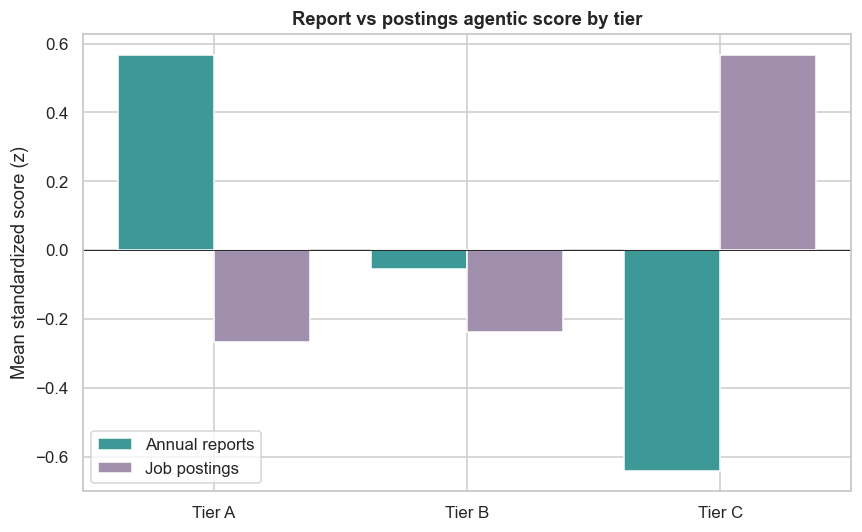

In [10]:
tier_cmp = m.groupby("tier").agg(
    n=("company","size"),
    mean_z_report=("z_report_share","mean"),
    mean_z_postings=("z_postings_total","mean"),
).reindex(["A","B","C"]).round(3)
print(tier_cmp.to_string())

fig, ax = plt.subplots(figsize=(8,5))
x=np.arange(3); w=0.38
#ax.bar(x-w/2, tier_cmp["mean_z_report"], w, label="Annual reports", color="#8ca7db")
#ax.bar(x+w/2, tier_cmp["mean_z_postings"], w, label="Job postings", color="#c99b38")
ax.bar(x-w/2, tier_cmp["mean_z_report"], w, label="Annual reports", color="#3c9997")
ax.bar(x+w/2, tier_cmp["mean_z_postings"], w, label="Job postings", color="#a190ad")
ax.set_xticks(x); ax.set_xticklabels(["Tier A","Tier B","Tier C"])
ax.axhline(0,color="k",lw=0.6)
ax.set_ylabel("Mean standardized score (z)")
ax.set_title("Report vs postings agentic score by tier")
ax.legend()
plt.tight_layout(); save(fig,"02_tier_comparison"); plt.show()


### 6. Annual-report progression over time
Reports-only (postings are a snapshot). All companies included; **year-coverage gaps flagged**.
Metric shown: `agentic_share_of_automation` (swap for any dimension column).

In [11]:
# coverage grid — who has which years
cov = ar.assign(x=1).pivot_table(index="company", columns="year", values="x",
                                 aggfunc="max", fill_value=0).astype(int)
print("Year coverage (1=present):")
print(cov.to_string())
incomplete = cov[(cov.sum(axis=1) < cov.shape[1])].index.tolist()
print(f"\nCompanies with INCOMPLETE year coverage (interpret trends cautiously): {incomplete}")


Year coverage (1=present):
year                       2022  2023  2024  2025
company                                          
AXA                           0     1     1     1
Admiral                       0     1     1     1
Ageas                         0     1     1     1
Allianz                       0     1     1     1
Alm Brand Group               0     1     1     1
Aviva                         0     1     1     1
Beazley                       0     1     1     1
Bolttech                      0     1     1     0
Coface                        0     1     1     1
Generali                      0     1     1     1
Gjensidige                    0     1     1     1
Helvetia Baloise              0     1     1     1
Hiscox                        0     1     1     1
Lemonade                      0     1     1     1
Linea Directa Aseguradora     0     1     1     1
Mapfre                        0     1     1     1
Marshmallow                   0     1     1     1
Munich Re              

  saved -> 04_progression_by_tier.png


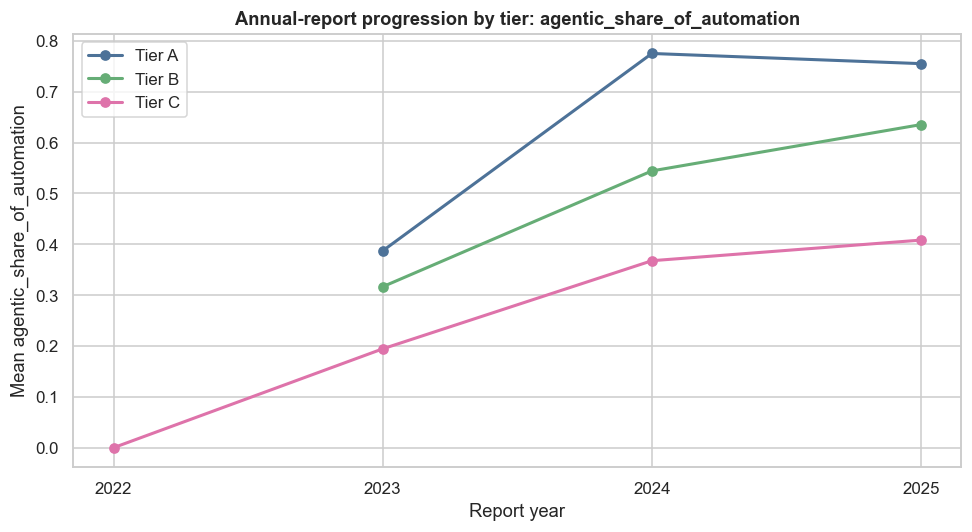

Companies behind each tier-year average:
tier   A  B  C
year          
2022   0  0  2
2023  11  9  9
2024  11  9  9
2025  11  9  6


In [12]:
# tier-average progression (smooths single-company noise)
METRIC = "agentic_share_of_automation"  # or "dim_tech_stack_per10k" or "dim_governance_per10k" or "dim_role_evolution_per10k"
tier_year = ar.groupby(["year","tier"])[METRIC].mean().reset_index()
fig, ax = plt.subplots(figsize=(9,5))
for t in ["A","B","C"]:
    s=tier_year[tier_year["tier"]==t]
    ax.plot(s["year"], s[METRIC], marker="o", linewidth=2,
            color=TIER_COLORS[t], label=f"Tier {t}")
ax.set_xticks(sorted(ar["year"].unique()))
ax.set_xlabel("Report year"); ax.set_ylabel(f"Mean {METRIC}")
ax.set_title(f"Annual-report progression by tier: {METRIC}")
ax.legend()
plt.tight_layout(); save(fig,"04_progression_by_tier"); plt.show()

# how many companies behind each tier-year point (thin cells = noisy)
print("Companies behind each tier-year average:")
print(ar.groupby(["year","tier"]).size().unstack(fill_value=0).to_string())


### 7. Divergence Table - Who Disagrees Most?

=== DIVERGENCE (positive = talks more than it hires; negative = hires more than it talks) ===
                  company tier  z_report_share  z_postings_total  divergence
                    Aviva    A        1.037856         -0.897965        1.94
         Helvetia Baloise    B        0.601248         -1.282542        1.88
                      AXA    A        0.448435         -1.276331        1.72
                   Talanx    A        0.769938         -0.872085        1.64
                   Zurich    A        0.910512         -0.619755        1.53
                   Mapfre    A        0.663621         -0.787975        1.45
                Munich Re    A        1.037856         -0.360955        1.40
                   Unipol    A        0.273792         -0.628554        0.90
                  Allianz    A        0.563379          0.010941        0.55
                   Hiscox    B        0.397828          0.058043        0.34
                  Admiral    B        0.861534          0.5

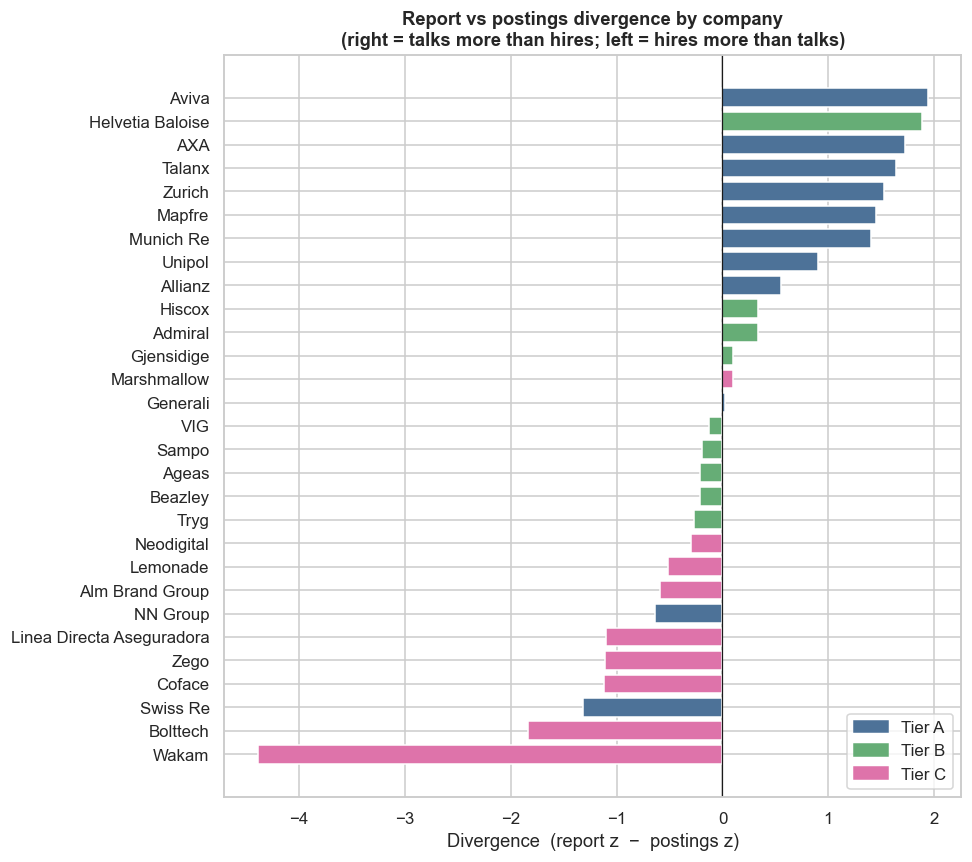

In [13]:
# divergence = report score minus postings score (both z-scored)
m["divergence"] = (m["z_report_share"] - m["z_postings_total"]).round(2)
div = m[["company","tier","z_report_share","z_postings_total","divergence"]].copy()
div = div.sort_values("divergence", ascending=False).reset_index(drop=True)

print("=== DIVERGENCE (positive = talks more than it hires; negative = hires more than it talks) ===")
print(div.to_string(index=False))
div.to_csv(FIG_DIR / "company_divergence.csv", index=False)

# chart
fig, ax = plt.subplots(figsize=(9, 8))
d = div.sort_values("divergence")
colors = [TIER_COLORS.get(t, "#888") for t in d["tier"]]
ax.barh(d["company"], d["divergence"], color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Divergence  (report z  −  postings z)")
ax.set_title("Report vs postings divergence by company\n(right = talks more than hires; left = hires more than talks)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=f"Tier {t}") for t,c in TIER_COLORS.items()], loc="lower right")
plt.tight_layout(); save(fig, "05_divergence"); plt.show()

### 8. Per Dimension Comparison

Spearman correlation: each report dimension vs postings metric
                postings_total  postings_agentic
agentic_share             0.15              0.22
role_evolution            0.26              0.37
tech_stack               -0.14              0.18
governance               -0.12              0.22
composite                 0.13              0.27
  saved -> 06_dimension_correlation_heatmap.png


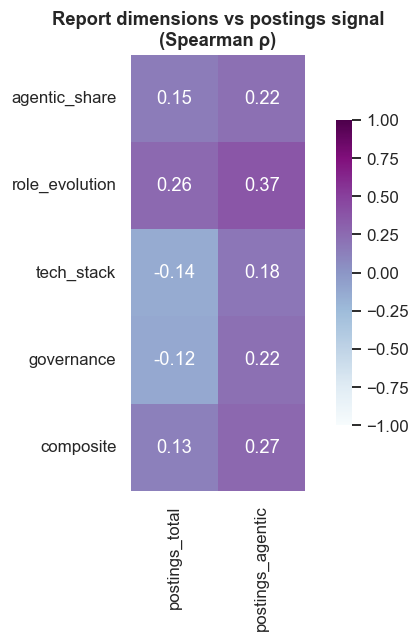

In [14]:
# correlate each report dimension against BOTH postings metrics
report_dims = {
    "agentic_share": "agentic_share_of_automation",
    "role_evolution": "dim_role_evolution_per10k",
    "tech_stack": "dim_tech_stack_per10k",
    "governance": "dim_governance_per10k",
    "composite": "rep_composite",
}
post_metrics = {"postings_total": "post_density_total", "postings_agentic": "post_density_agentic"}

corr_rows = []
for rlabel, rcol in report_dims.items():
    row = {}
    for plabel, pcol in post_metrics.items():
        rho, _ = stats.spearmanr(m[rcol], m[pcol])
        row[plabel] = round(rho, 2)
    corr_rows.append(pd.Series(row, name=rlabel))
corr_df = pd.DataFrame(corr_rows)
print("Spearman correlation: each report dimension vs postings metric")
print(corr_df.to_string())

import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="BuPu", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Report dimensions vs postings signal\n(Spearman ρ)")
plt.tight_layout(); save(fig, "06_dimension_correlation_heatmap"); plt.show()

### 9. Company Archetypes

  saved -> 07_archetype_quadrants.png


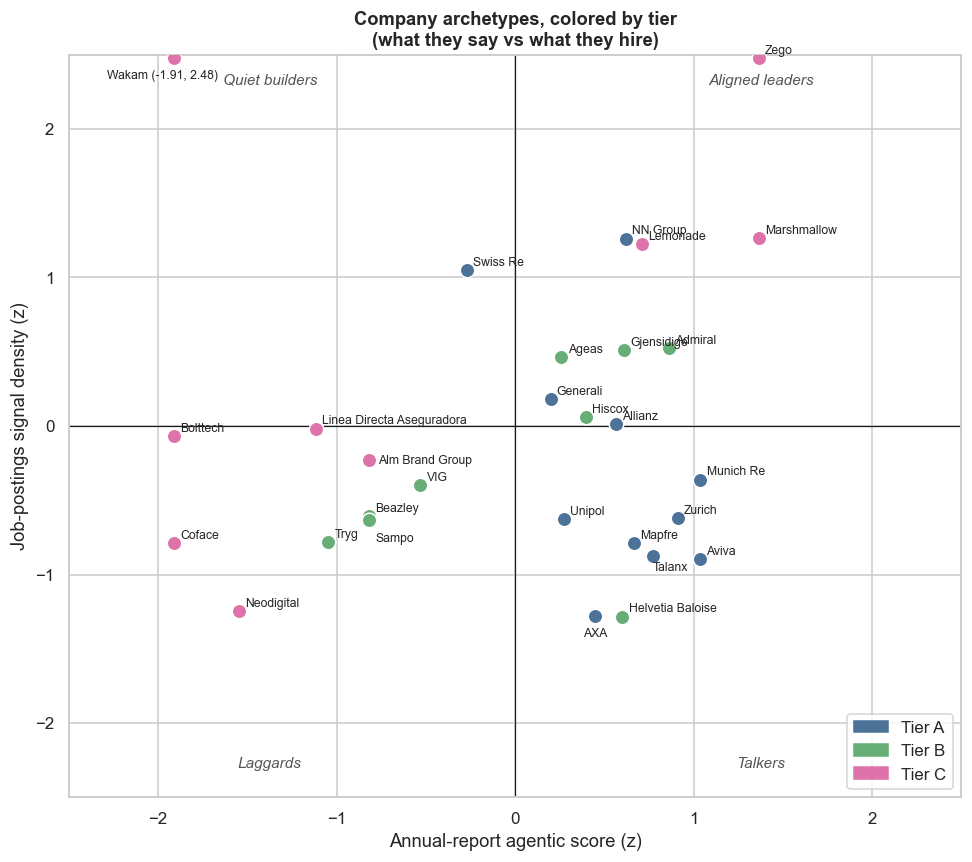

In [15]:
# quadrant scatter — dots colored by TIER, quadrant labels name the archetypes
fig, ax = plt.subplots(figsize=(9, 8))
for _, r in m.iterrows():
    ax.scatter(r["z_report_share"], r["z_postings_total"], s=90,
               color=TIER_COLORS.get(r["tier"], "#888"), zorder=3, edgecolor="white")

    # per-company label placement -- overlapping/cramped default positions get a manual override
    if r["company"] == "Wakam":
        # one-off: label sits directly below the dot, scores included since it's the most extreme point
        label = f"{r['company']} ({r['z_report_share']:.2f}, {r['z_postings_total']:.2f})"
        ax.annotate(label, (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(-8, -8), textcoords="offset points", va="top", ha="center")
    elif r["company"] == "AXA":
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(0, -8), textcoords="offset points", va="top", ha="center")
    elif r["company"] == "Sampo":
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(4, -8), textcoords="offset points", va="top", ha="left")
    elif r["company"] == "Alm Brand Group":
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(6, 0), textcoords="offset points", va="center", ha="left")
    elif r["company"] == "Talanx":
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(0, -8), textcoords="offset points", va="center", ha="left")
    else:
        ax.annotate(r["company"], (r["z_report_share"], r["z_postings_total"]),
                    fontsize=8, xytext=(4,3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
lim = 2.5; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

# quadrant labels (grey, in the corners) so archetype + tier are both readable
ax.text(lim*0.55,  lim*0.92, "Aligned leaders", color="#555", fontsize=10, ha="center", style="italic")
ax.text(-lim*0.55, lim*0.92, "Quiet builders", color="#555", fontsize=10, ha="center", style="italic")
ax.text(lim*0.55, -lim*0.92, "Talkers",         color="#555", fontsize=10, ha="center", style="italic")
ax.text(-lim*0.55,-lim*0.92, "Laggards",        color="#555", fontsize=10, ha="center", style="italic")


ax.set_xlabel("Annual-report agentic score (z)")
ax.set_ylabel("Job-postings signal density (z)")
ax.set_title("Company archetypes, colored by tier\n(what they say vs what they hire)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=f"Tier {t}") for t,c in TIER_COLORS.items()], loc="lower right")
plt.tight_layout(); save(fig, "07_archetype_quadrants"); plt.show()

In [16]:
print(m["company"].unique())

<ArrowStringArray>
[                     'Zego',               'Marshmallow',
                     'Aviva',                 'Munich Re',
                    'Zurich',                   'Admiral',
                    'Talanx',                  'Lemonade',
                    'Mapfre',                  'NN Group',
                'Gjensidige',          'Helvetia Baloise',
                   'Allianz',                       'AXA',
                    'Hiscox',                    'Unipol',
                     'Ageas',                  'Generali',
                  'Swiss Re',                       'VIG',
                   'Beazley',                     'Sampo',
           'Alm Brand Group',                      'Tryg',
 'Linea Directa Aseguradora',                'Neodigital',
                    'Coface',                  'Bolttech',
                     'Wakam']
Length: 29, dtype: str


### 10. Final AMI Score — Combining the Two Tracks

Group decision: **simple averaging of the report-z and postings-z scores is off the table** — the two
tracks measure genuinely different things (what a firm *says* vs. what it *hires for*), and a plain
average would let a firm's talk quietly cancel out weak hiring (or vice versa).

Two alternatives were considered against the cell-based approach used below: a **bottleneck** score
(driven by the weaker of the two tracks) and a **penalized distance-from-origin** score (continuous,
tunable via a single lambda). Both were ruled out in favor of the cell-based method for its
interpretability to a non-technical audience. The explicit 4x4 lookup table
can be read and sanity-checked cell by cell, where the other two require trusting a formula.

- **10a. Cell-based** — bins each company into a 4x4 report x postings grid and looks up a score from
  an explicit, hand-inspectable matrix. Producing a company-level **0–100 AMI score** and a
  **Phase 1 (Assisted) / Phase 2 (Augmented) / Phase 3 (Frontier)** bucket, using equal thirds of the
  0–100 range as the default cut points (33.3 / 66.7 — tunable, same spirit as the dimension-weight
  sensitivity checks elsewhere in this notebook).

In [17]:
# ---- shared helpers for all 3 scoring methods ----
PHASE_ORDER  = ["Phase 1 - Assisted", "Phase 2 - Augmented", "Phase 3 - Frontier"]
PHASE_COLORS = {"Phase 1 - Assisted": "#67839c",
                 "Phase 2 - Augmented": "#739480",
                 "Phase 3 - Frontier": "#cc9dc2"}

def minmax_100(s):
    """Rescale a numeric series to 0-100 across the sample (same convention as the AMI dimensions)."""
    lo, hi = s.min(), s.max()
    return ((s - lo) / (hi - lo) * 100) if hi > lo else pd.Series(50.0, index=s.index)

def phase_from_score(score):
    if score < 33.34:  return "Phase 1 - Assisted"
    elif score < 66.67: return "Phase 2 - Augmented"
    return "Phase 3 - Frontier"

def qbin(s, n=4):
    """Rank-based quantile binning -> robust to the tied/floor z-scores in this dataset
    (several companies share the same zero-signal floor, which breaks a plain qcut)."""
    return pd.qcut(s.rank(method="first"), n, labels=False)

print("Helpers ready.")

Helpers ready.


#### 10a. Cell-based (4x4 matrix lookup)

Each company is binned into a quartile (Low / Med-Low / Med-High / High) on each track, giving a
4x4 = 16-cell grid. Each cell has an explicit score, built as *(average of the two bin positions)*,
**penalized by how far apart the two bins are**, so a company that's High/High scores 100, but a
company that's High/Low (all talk, or all hiring, no alignment) scores well below a company that's
Med-High/Med-High, even though their raw bin totals could otherwise tie. `GAP_PENALTY` is the tunable
knob (points deducted per bin of mismatch).

In [18]:
GAP_PENALTY = 12  # points deducted per bin of mismatch between the two tracks -- tune & sensitivity-check

def cell_score(rep_bin, post_bin, penalty=GAP_PENALTY):
    base = (rep_bin + post_bin) / 6 * 100          # 0-100 from the average bin position
    gap  = abs(rep_bin - post_bin)                  # 0-3: how mismatched the two tracks are
    return max(0.0, base - penalty * gap)

m["report_bin"]   = qbin(m["z_report_share"])
m["postings_bin"] = qbin(m["z_postings_total"])
m["score_cell"]   = m.apply(lambda r: cell_score(r["report_bin"], r["postings_bin"]), axis=1)
m["phase_cell"]   = m["score_cell"].apply(phase_from_score)

cell_table = pd.DataFrame({pb: [cell_score(rb, pb) for rb in range(4)] for pb in range(4)}, index=range(4))
cell_table.index.name = "report_bin"; cell_table.columns.name = "postings_bin"
print("Cell lookup table (rows=report bin, cols=postings bin):")
print(cell_table.round(1).to_string())
print()
print(m[["company","tier","report_bin","postings_bin","score_cell","phase_cell"]]
      .sort_values("score_cell", ascending=False).round(1).to_string(index=False))

Cell lookup table (rows=report bin, cols=postings bin):
postings_bin     0     1     2      3
report_bin                           
0              0.0   4.7   9.3   14.0
1              4.7  33.3  38.0   42.7
2              9.3  38.0  66.7   71.3
3             14.0  42.7  71.3  100.0

                  company tier  report_bin  postings_bin  score_cell          phase_cell
                     Zego    C           3             3       100.0  Phase 3 - Frontier
                  Admiral    B           3             3       100.0  Phase 3 - Frontier
              Marshmallow    C           3             3       100.0  Phase 3 - Frontier
                 Lemonade    C           2             3        71.3  Phase 3 - Frontier
                 NN Group    A           2             3        71.3  Phase 3 - Frontier
                  Allianz    A           2             2        66.7 Phase 2 - Augmented
               Gjensidige    B           2             2        66.7 Phase 2 - Augmented
   

  saved -> ami_final_scores.png


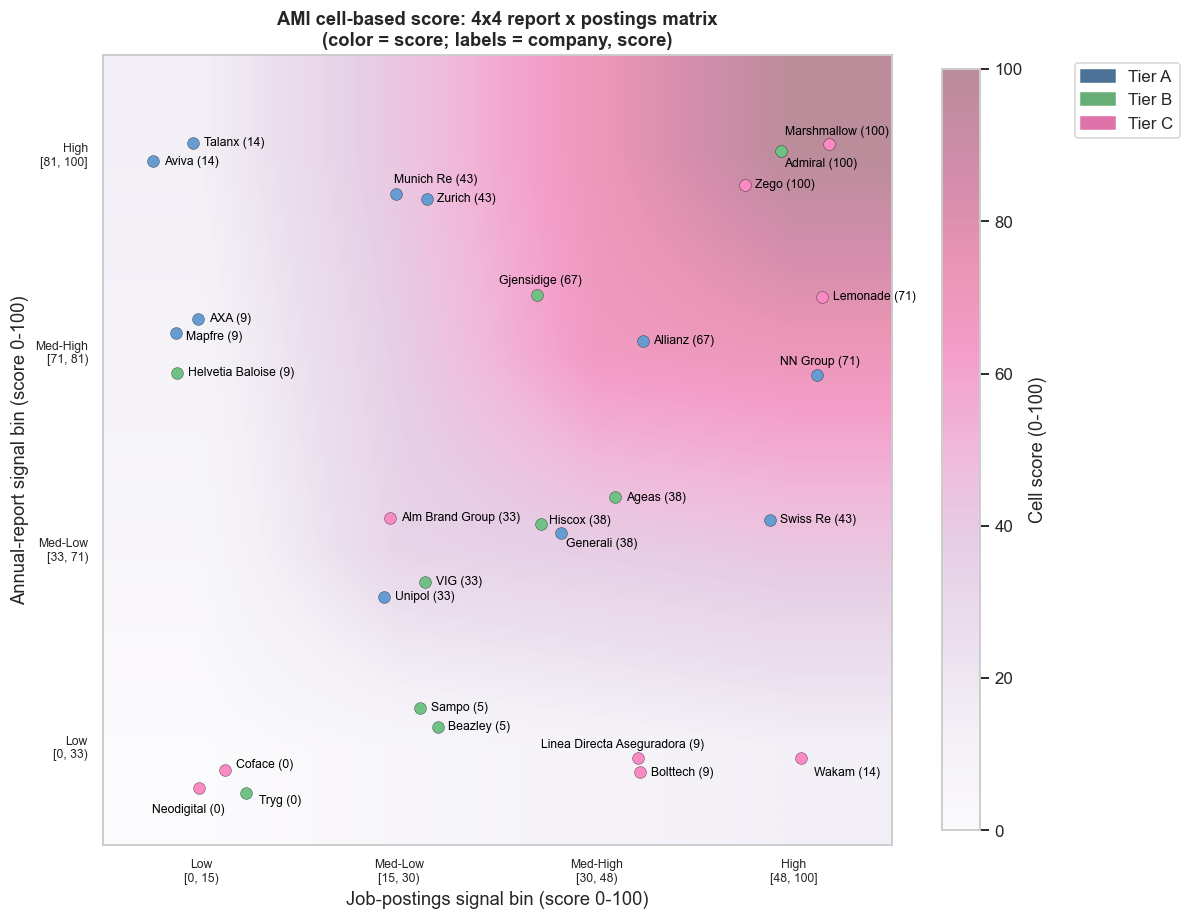

In [19]:
# 4x4 matrix visual -- color-coded grid (per Sabine's request), companies plotted in their cell
bin_labels = ["Low", "Med-Low", "Med-High", "High"]

TIER_COLORS_AMI={"A": "#659cd2", "B": "#6fc283", "C": "#fa8ac4"}


# axis tick ranges shown on the 0-100 SCORE scale (not raw z), for readability
m["report_score_100"]   = minmax_100(m["z_report_share"])
m["postings_score_100"] = minmax_100(m["z_postings_total"])

def bin_range_labels(score_col, bin_col):
    """Half-open intervals on one shared cut point per boundary: no overlaps, no gaps."""
    cuts = [m[score_col].min()]
    for b in range(3):
        top = m.loc[m[bin_col] == b,     score_col].max()
        nxt = m.loc[m[bin_col] == b + 1, score_col].min()
        cuts.append((top + nxt) / 2)          # midpoint of the empty span between bins
    cuts.append(m[score_col].max())

    labels = []
    for b in range(4):
        close = "]" if b == 3 else ")"        # top bin closed on the right
        labels.append(f"{bin_labels[b]}\n[{cuts[b]:.0f}, {cuts[b+1]:.0f}{close}")
    return labels

fig, ax = plt.subplots(figsize=(11, 9.5))
ax.grid(False)
grid = cell_table.values

im = ax.imshow(grid, cmap="PuRd", vmin=0, vmax=100, origin="lower", aspect="equal", alpha=0.45, interpolation="bilinear")
cbar = plt.colorbar(im, ax=ax, shrink=0.8); cbar.set_label("Cell score (0-100)")

ax.set_xticks(range(4)); ax.set_xticklabels(bin_range_labels("postings_score_100", "postings_bin"), fontsize=8)
ax.set_yticks(range(4)); ax.set_yticklabels(bin_range_labels("report_score_100", "report_bin"), fontsize=8)
ax.set_xlabel("Job-postings signal bin (score 0-100)"); ax.set_ylabel("Annual-report signal bin (score 0-100)")
ax.set_title("AMI cell-based score: 4x4 report x postings matrix\n(color = score; labels = company, score)")

rng = np.random.default_rng(3)
for _, r in m.iterrows():
    jx = r["postings_bin"] + rng.uniform(-0.3, 0.3)
    jy = r["report_bin"]   + rng.uniform(-0.3, 0.3)
    ax.scatter(jx, jy, s=60, color=TIER_COLORS_AMI.get(r["tier"], "#333"), edgecolor="black", zorder=3, linewidth=0.2)

    if r["company"] == "Mapfre":
        # one-off: label sits directly above the dot, like the original style
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(25, -6), textcoords="offset points", va="bottom", ha="center", color="black")
    elif r["company"] == "Marshmallow":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(5, 12), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Admiral":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(26, -4), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Gjensidige":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(2, 13), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Wakam":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(30, -6), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Generali":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(26, -3), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Hiscox":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(26, 6), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Coface":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(26, 8), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Tryg":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(22, -1), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Linea Directa Aseguradora":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(-10, 13), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "NN Group":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(2, 13), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Munich Re":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(26, 13), textcoords="offset points", va="top", ha="center", color="black")
    elif r["company"] == "Neodigital":
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(-7, -10), textcoords="offset points", va="top", ha="center", color="black")
    else:
        ax.annotate(f"{r['company']} ({r['score_cell']:.0f})", (jx, jy), fontsize=8,
                    xytext=(7, 0), textcoords="offset points", va="center", ha="left", color="black")



from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=f"Tier {t}") for t, c in TIER_COLORS.items()],
          loc="upper left", bbox_to_anchor=(1.22, 1.0))
plt.tight_layout(); save(fig, "ami_final_scores"); plt.show()

#### 10a. GAP_PENALTY Sensitivity Check

Same spirit as the SFCR and Wakam-exclusion sensitivity checks elsewhere in this notebook.
`GAP_PENALTY=12` is a tunable knob, not a fitted parameter. There's no ground-truth AMI
score to optimize against, so "proper tuning" here means showing the ranking and phase
assignments are *robust* to the exact value chosen, not picking a value that minimizes a loss.

 penalty  spearman_vs_default   phase_flips_vs_default   n_floored_to_0
       0               0.9554                        3                3
       4               0.9865                        3                3
       8               1.0000                        0                3
      12               1.0000                        0                3  <- default
      16               1.0000                        0                3
      20               0.8970                        8               13
      24               0.8970                        8               13
      30               0.8970                        8               13
      40               0.7891                        8               16
  saved -> 10a_sens_gap_penalty.png


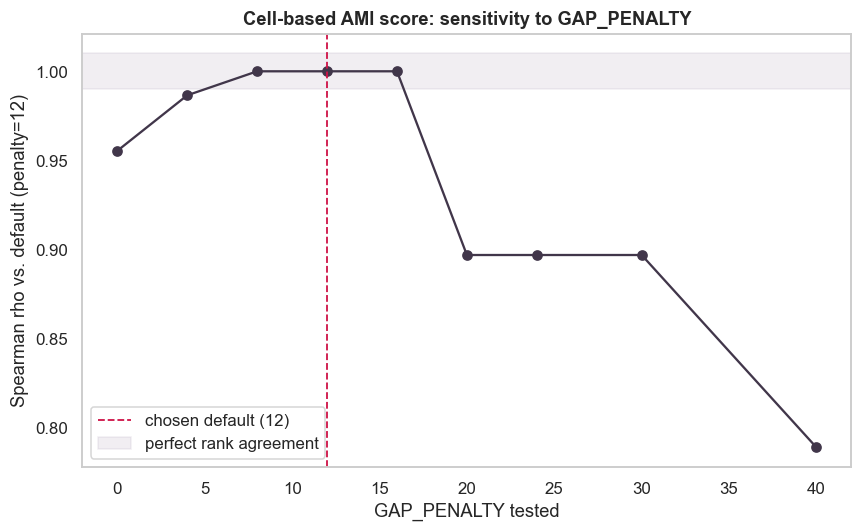


Interpretation: rankings and phase assignments are identical for penalty in [8, 16] (the default of 12 sits inside this plateau).
 Above ~20 the penalty starts overriding the base score entirely -- companies getfloored to 0 regardless of raw signal strength, 
 which stops rewarding partial strength on one track and just punishes any imbalance.


In [20]:
from scipy.stats import spearmanr

PENALTY_RANGE = [0, 4, 8, 12, 16, 20, 24, 30, 40]
BASELINE_PENALTY = GAP_PENALTY  # 12

scores_by_penalty = {
    pen: m.apply(lambda r: cell_score(r["report_bin"], r["postings_bin"], pen), axis=1)
    for pen in PENALTY_RANGE
}
baseline_scores = scores_by_penalty[BASELINE_PENALTY]
baseline_phases = baseline_scores.apply(phase_from_score)

print(f"{'penalty':>8} {'spearman_vs_default':>20} {'phase_flips_vs_default':>24} {'n_floored_to_0':>16}")
for pen in PENALTY_RANGE:
    s = scores_by_penalty[pen]
    rho, _ = spearmanr(s, baseline_scores)
    n_flips = (s.apply(phase_from_score) != baseline_phases).sum()
    n_zero = (s == 0).sum()
    marker = "  <- default" if pen == BASELINE_PENALTY else ""
    print(f"{pen:>8} {rho:>20.4f} {n_flips:>24} {n_zero:>16}{marker}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)
rhos = [spearmanr(scores_by_penalty[pen], baseline_scores)[0] for pen in PENALTY_RANGE]
ax.plot(PENALTY_RANGE, rhos, "o-", color="#41364a")
ax.axvline(BASELINE_PENALTY, color="#cf1549", lw=1.2, ls="--", label=f"chosen default ({BASELINE_PENALTY})")
ax.axhspan(0.99, 1.01, color="#a190ad", alpha=0.15, label="perfect rank agreement")
ax.set_xlabel("GAP_PENALTY tested")
ax.set_ylabel(f"Spearman rho vs. default (penalty={BASELINE_PENALTY})")
ax.set_title("Cell-based AMI score: sensitivity to GAP_PENALTY")
ax.legend()
plt.tight_layout(); save(fig, "10a_sens_gap_penalty"); plt.show()

print(f"\nInterpretation: rankings and phase assignments are identical for penalty in "
      f"[8, 16] (the default of {BASELINE_PENALTY} sits inside this plateau).\n "
      f"Above ~20 the penalty starts overriding the base score entirely -- companies get"
      f"floored to 0 regardless of raw signal strength, \n which stops rewarding partial "
      f"strength on one track and just punishes any imbalance.")

In [21]:
def cell_score_gp(report_bin, postings_bin, gp):
    base = (report_bin + postings_bin) / 6 * 100
    return max(0.0, base - gp * abs(report_bin - postings_bin))

for gp in [0, 12]:
    m[f"score_gp{gp}"] = [cell_score_gp(rb, pb, gp)
                          for rb, pb in zip(m["report_bin"], m["postings_bin"])]

# sanity: gp=12 must reproduce the published scores
assert np.allclose(m["score_gp12"], m["score_cell"]), "formula does not match score_cell"

rho, p = stats.spearmanr(m["score_gp0"], m["score_gp12"])
delta  = (m["score_gp0"] - m["score_gp12"]).abs()
ph0, ph12 = m["score_gp0"].apply(phase_from_score), m["score_gp12"].apply(phase_from_score)

print(f"Spearman rho (penalty 0 vs 12): {rho:.3f}  p={p:.4f}")
print(f"Phase changes: {(ph0 != ph12).sum()} of {len(m)}")
print(f"Mean |score change|: {delta.mean():.1f}   Max: {delta.max():.1f}")
print(m.assign(d=delta).nlargest(6, "d")[
    ["company","report_bin","postings_bin","score_gp0","score_gp12","d"]].to_string(index=False))

Spearman rho (penalty 0 vs 12): 0.955  p=0.0000
Phase changes: 3 of 29
Mean |score change|: 13.2   Max: 36.0
  company  report_bin  postings_bin  score_gp0  score_gp12    d
    Aviva           3             0  50.000000   14.000000 36.0
   Talanx           3             0  50.000000   14.000000 36.0
    Wakam           0             3  50.000000   14.000000 36.0
Munich Re           3             1  66.666667   42.666667 24.0
   Zurich           3             1  66.666667   42.666667 24.0
   Mapfre           2             0  33.333333    9.333333 24.0


#### 10b. Job-Posting Reliability Shrinkage Sensitivity Check

Some companies' postings signal rests on very few scraped jobs and a thin sample can land a company at an extreme
z-score from noise alone rather than genuine signal. This check tests whether
shrinking low-volume companies' postings z-score toward the sample-neutral center,
in proportion to how much evidence they actually have, changes any company's final
archetype or maturity phase.

`reliability = min(1, n_postings / RELIABILITY_THRESHOLD)`
`z_postings_shrunk = reliability * z_postings_total`

`RELIABILITY_THRESHOLD` is a tunable knob, same spirit as `GAP_PENALTY` above.
10 matches the existing >10-posting cutoff already used for the low-volume
footnote (Línea Directa, Alm Brand, Bolttech, Lemonade, Munich Re, Alm Brand Group); 20 is tested as an
alternative, and a full sweep checks stability across the range.

In [22]:
# Reliability-weighted shrinkage sensitivity check shrinks each company's postings z-score toward the SAMPLE MEAN in proportion to how many usable postings it has.

# Note: the earlier form (reliability * z) shrank toward zero, which cannot change the sign of z — so the sign-based archetype label was
# invariant by construction and the archetype column was not a real test. Shrinking toward the sample mean is the standard estimator and
# can in principle move a company across an axis.

def archetype_from_z(z_rep, z_post):
    rep_hi, post_hi = z_rep >= 0, z_post >= 0
    if rep_hi and post_hi:       return "Aligned Leaders"
    if rep_hi and not post_hi:   return "Talkers"
    if not rep_hi and post_hi:   return "Quiet Builders"
    return "Laggards"

RELIABILITY_THRESHOLD = 10   # aligns with the <10 low-volume convention used in the
                            # postings figures and MIN_POSTINGS_SENIORITY

def apply_shrinkage(df, threshold=RELIABILITY_THRESHOLD):
    d = df.copy()
    d["reliability"] = np.minimum(1.0, d["n_postings"] / threshold)
    mu = d["z_postings_total"].mean()          # sample mean of the postings z-score
    d["z_postings_shrunk"] = mu + d["reliability"] * (d["z_postings_total"] - mu)
    return d

m_shrunk = apply_shrinkage(m, RELIABILITY_THRESHOLD)
m_shrunk["postings_bin_shrunk"] = qbin(m_shrunk["z_postings_shrunk"])
m_shrunk["score_shrunk"] = m_shrunk.apply(
    lambda r: cell_score(r["report_bin"], r["postings_bin_shrunk"]), axis=1)
m_shrunk["phase_shrunk"] = m_shrunk["score_shrunk"].apply(phase_from_score)

m_shrunk["archetype_orig"] = [archetype_from_z(rz, pz) for rz, pz in
                              zip(m_shrunk["z_report_share"], m_shrunk["z_postings_total"])]
m_shrunk["archetype_shrunk"] = [archetype_from_z(rz, pz) for rz, pz in
                                zip(m_shrunk["z_report_share"], m_shrunk["z_postings_shrunk"])]

comp = m_shrunk[["company","tier","n_postings","reliability",
                 "postings_bin","postings_bin_shrunk",
                 "score_cell","score_shrunk",
                 "phase_cell","phase_shrunk",
                 "archetype_orig","archetype_shrunk"]].copy()
comp["score_delta"]       = (comp["score_shrunk"] - comp["score_cell"]).round(1)
comp["bin_changed"]       = comp["postings_bin"] != comp["postings_bin_shrunk"]
comp["archetype_changed"] = comp["archetype_orig"] != comp["archetype_shrunk"]
comp["phase_changed"]     = comp["phase_cell"] != comp["phase_shrunk"]
comp = comp.sort_values("n_postings").reset_index(drop=True)   # table order = volume ascending

comp.to_csv(FIG_DIR / "10b_reliability_shrinkage_sensitivity.csv", index=False)

mu = m_shrunk["z_postings_total"].mean()
print(f"Reliability threshold theta   = {RELIABILITY_THRESHOLD} usable postings")
print(f"Sample mean of postings z     = {mu:.4f}")
print(f"Companies actually shrunk     : {int((comp['reliability'] < 1.0).sum())} of {len(comp)}")
print(f"Companies w/ postings-bin chg : {comp['bin_changed'].sum()}")
print(f"Companies w/ archetype change : {comp['archetype_changed'].sum()}")
print(f"Companies w/ phase change     : {comp['phase_changed'].sum()}")
print(f"Max |score delta|             : {comp['score_delta'].abs().max():.1f}")
print()
print(comp.round(2).to_string(index=False))

# ---- sweep across theta so the reported stability range is actually evidenced ----
print("\n--- theta sweep ---")
print(f"{'theta':>6} {'n_shrunk':>9} {'bin_chg':>8} {'arch_chg':>9} {'phase_chg':>10} {'max|d|':>7}")
for th in range(2, 31):
    s = apply_shrinkage(m, th)
    s["pb"] = qbin(s["z_postings_shrunk"])
    s["sc"] = s.apply(lambda r: cell_score(r["report_bin"], r["pb"]), axis=1)
    s["ph"] = s["sc"].apply(phase_from_score)
    ar_new = [archetype_from_z(rz, pz) for rz, pz in
              zip(s["z_report_share"], s["z_postings_shrunk"])]
    ar_old = [archetype_from_z(rz, pz) for rz, pz in
              zip(s["z_report_share"], s["z_postings_total"])]
    print(f"{th:>6} {int((s['reliability'] < 1).sum()):>9} "
          f"{int((s['pb'] != s['postings_bin']).sum()):>8} "
          f"{sum(a != b for a, b in zip(ar_new, ar_old)):>9} "
          f"{int((s['ph'] != s['phase_cell']).sum()):>10} "
          f"{(s['sc'] - s['score_cell']).abs().max():>7.1f}")

Reliability threshold theta   = 10 usable postings
Sample mean of postings z     = 0.0000
Companies actually shrunk     : 5 of 29
Companies w/ postings-bin chg : 2
Companies w/ archetype change : 0
Companies w/ phase change     : 2
Max |score delta|             : 4.7

                  company tier  n_postings  reliability  postings_bin  postings_bin_shrunk  score_cell  score_shrunk          phase_cell        phase_shrunk  archetype_orig archetype_shrunk  score_delta  bin_changed  archetype_changed  phase_changed
                 Bolttech    C           2          0.2             2                    2        9.33          9.33  Phase 1 - Assisted  Phase 1 - Assisted        Laggards         Laggards          0.0        False              False          False
                 Lemonade    C           4          0.4             3                    2       71.33         66.67  Phase 3 - Frontier Phase 2 - Augmented Aligned Leaders  Aligned Leaders         -4.7         True              Fa

 threshold   spearman_vs_baseline   phase_flips    archetype_flips
         5                 1.0000             0                  0
        10                 0.9980             2                  0
        15                 0.9949             2                  0
        20                 0.9949             2                  0
        25                 0.9630             2                  0
        30                 0.9630             2                  0
  saved -> 10b_sens_reliability_threshold.png


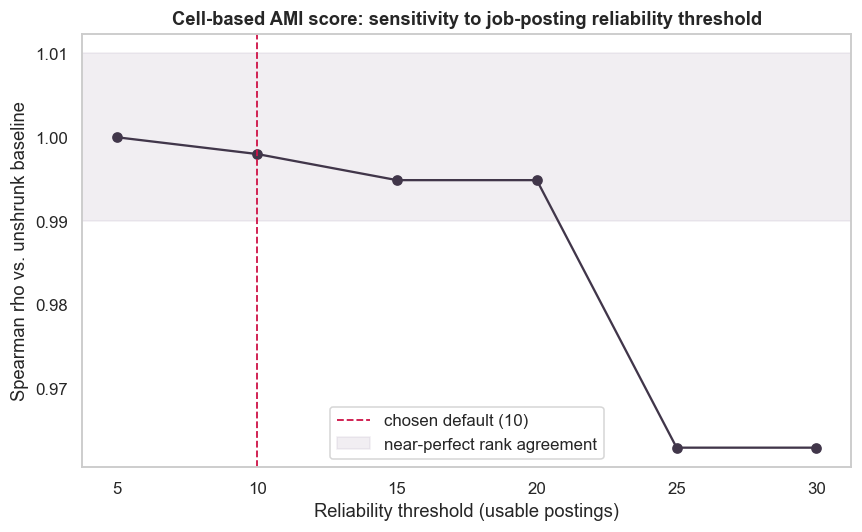


Interpretation: archetype and phase assignments are unchanged for all 29 companies across thresholds 5-30. Two companies (Ageas, Línea Directa Aseguradora) show a modest cell-score shift (~5 points) at thresholds ≥10, both remaining within their assigned phase.


In [23]:
# sensitivity sweep across candidate reliability thresholds
# Baseline = current locked method (no shrinkage). Tests whether adding this adjustment, and how aggressively, changes rankings, phases, or archetypes.
THRESHOLD_RANGE = [5, 10, 15, 20, 25, 30]

baseline_scores     = m["score_cell"]
baseline_phases      = m["phase_cell"]
baseline_archetypes = [archetype_from_z(rz, pz) for rz, pz in
                        zip(m["z_report_share"], m["z_postings_total"])]

print(f"{'threshold':>10} {'spearman_vs_baseline':>22} {'phase_flips':>13} {'archetype_flips':>18}")
sweep_rows = []
for th in THRESHOLD_RANGE:
    d  = apply_shrinkage(m, th)
    pb = qbin(d["z_postings_shrunk"])
    sc = [cell_score(rb, pb_) for rb, pb_ in zip(m["report_bin"], pb)]
    ph = [phase_from_score(s) for s in sc]
    ar = [archetype_from_z(rz, pz) for rz, pz in zip(m["z_report_share"], d["z_postings_shrunk"])]

    rho, _        = spearmanr(sc, baseline_scores)
    n_phase_flip  = sum(p1 != p2 for p1, p2 in zip(ph, baseline_phases))
    n_arch_flip   = sum(a1 != a2 for a1, a2 in zip(ar, baseline_archetypes))
    sweep_rows.append((th, rho, n_phase_flip, n_arch_flip))
    print(f"{th:>10} {rho:>22.4f} {n_phase_flip:>13} {n_arch_flip:>18}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)
rhos = [r[1] for r in sweep_rows]
ax.plot(THRESHOLD_RANGE, rhos, "o-", color="#41364a")
ax.axvline(RELIABILITY_THRESHOLD, color="#cf1549", lw=1.2, ls="--",
           label=f"chosen default ({RELIABILITY_THRESHOLD})")
ax.axhspan(0.99, 1.01, color="#a190ad", alpha=0.15, label="near-perfect rank agreement")
ax.set_xlabel("Reliability threshold (usable postings)")
ax.set_ylabel("Spearman rho vs. unshrunk baseline")
ax.set_title("Cell-based AMI score: sensitivity to job-posting reliability threshold")
ax.legend()
plt.tight_layout(); save(fig, "10b_sens_reliability_threshold"); plt.show()

print(f"\nInterpretation: archetype and phase assignments are unchanged for all "
      f"29 companies across thresholds 5-30. Two companies (Ageas, Línea Directa "
      f"Aseguradora) show a modest cell-score shift (~5 points) at thresholds "
      f"≥10, both remaining within their assigned phase.")

### 11. Sensitivity Check: with or without SFCR/Financial Statement Tier C companies

**Companies with no annual reports:**
- SFCR only: Wakam, Lemonade, and Marshmallow 
- Financial Statements only: Bolttech, Zego

These reports are narrow regulatory filings unlikely to discuss AI/automation strategy regardless of the company's actual maturity. 
This checks whether the headline results depend on including them, rather than deciding upfront to drop them.

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

SFCR_ONLY = ["Wakam", "bolttech", "Bolttech", "Lemonade", "Marshmallow", "Zego"]

ARCHETYPE_LABELS = [
    archetype_from_z(+1, +1),   # Aligned Leaders
    archetype_from_z(+1, -1),   # Talkers
    archetype_from_z(-1, +1),   # Quiet Builders
    archetype_from_z(-1, -1),   # Laggards
]


def build_scenario(base, exclude=None):
    """Recompute z-scores (and therefore archetype) fresh on whichever
    companies are in scope -- NOT just filtering the existing z-scored rows.
    Removing extreme values shifts the mean/std of everyone else too, so this
    is the fair test of whether the outliers are quietly rescaling the
    remaining companies' classification, not just their own."""
    d = base.copy()
    if exclude:
        d = d[~d["company"].isin(exclude)].copy()
    d["z_report_share"]   = zscore(d["agentic_share_of_automation"])
    d["z_postings_total"] = zscore(d["post_density_total"])
    d["archetype"] = d.apply(
        lambda r: archetype_from_z(r["z_report_share"], r["z_postings_total"]), axis=1)
    return d


def run_scenario(data, label, k=4):
    print(f"\n{'='*65}\n{label}  (n={len(data)})\n{'='*65}")
    rho, pval = stats.spearmanr(data["z_report_share"], data["z_postings_total"])
    print(f"Spearman rho (report vs postings) = {rho:+.3f}, p={pval:.3f}")

    print("\nArchetype counts:")
    counted = 0
    for a in ARCHETYPE_LABELS:
        names = data[data["archetype"] == a]["company"].tolist()
        counted += len(names)
        print(f"  {a:18s} ({len(names)}): {', '.join(names) if names else '--'}")

    # guard: every company must land in exactly one bucket
    assert counted == len(data), (
        f"Archetype counts sum to {counted} but there are {len(data)} companies. "
        f"Labels in data: {sorted(data['archetype'].unique())} vs "
        f"labels checked: {ARCHETYPE_LABELS}"
    )

    k_eff = min(k, len(data) - 1)   # guard against k > n on the smaller sample
    X = data[["z_report_share", "z_postings_total"]].values
    km = KMeans(n_clusters=k_eff, random_state=42, n_init=10).fit(X)
    ari = adjusted_rand_score(data["archetype"], km.labels_)
    print(f"\nk-means (k={k_eff}) ARI vs manual archetype = {ari:.3f}")
    return {"rho": rho, "pval": pval, "ari": ari, "n": len(data)}


scenario_full = build_scenario(m)
scenario_excl = build_scenario(m, exclude=SFCR_ONLY)

res_full = run_scenario(scenario_full, "FULL SAMPLE (all companies)")
res_excl = run_scenario(
    scenario_excl,
    "EXCLUDING Tier C: SFCR-only (Wakam, Lemonade, Marshmallow) and "
    "Financial Statements-only (Bolttech, Zego)")

comparison = pd.DataFrame([
    {"scenario": "Full sample", **res_full},
    {"scenario": "Excl. SFCR-only", **res_excl},
]).set_index("scenario")
print("\n\n=== SIDE-BY-SIDE COMPARISON ===")
print(comparison.round(3).to_string())

# the more interesting question: do any REMAINING companies change archetype
# once the scale is recalculated without the outliers stretching it?
merged_check = scenario_full[["company", "archetype"]].merge(
    scenario_excl[["company", "archetype"]], on="company", suffixes=("_full", "_excl"))
flips = merged_check[merged_check["archetype_full"] != merged_check["archetype_excl"]]
print("\n=== Remaining companies that flip archetype once rescaled without the outliers ===")
print(flips.to_string(index=False) if len(flips) else "None -- no remaining company changes classification.")


FULL SAMPLE (all companies)  (n=29)
Spearman rho (report vs postings) = +0.148, p=0.443

Archetype counts:
  Aligned Leaders    (10): Zego, Marshmallow, Admiral, Lemonade, NN Group, Gjensidige, Allianz, Hiscox, Ageas, Generali
  Talkers            (8): Aviva, Munich Re, Zurich, Talanx, Mapfre, Helvetia Baloise, AXA, Unipol
  Quiet Builders     (2): Swiss Re, Wakam
  Laggards           (9): VIG, Beazley, Sampo, Alm Brand Group, Tryg, Linea Directa Aseguradora, Neodigital, Coface, Bolttech

k-means (k=4) ARI vs manual archetype = 0.678

EXCLUDING Tier C: SFCR-only (Wakam, Lemonade, Marshmallow) and Financial Statements-only (Bolttech, Zego)  (n=24)
Spearman rho (report vs postings) = +0.055, p=0.799

Archetype counts:
  Aligned Leaders    (7): Admiral, NN Group, Gjensidige, Allianz, Hiscox, Ageas, Generali
  Talkers            (8): Aviva, Munich Re, Zurich, Talanx, Mapfre, Helvetia Baloise, AXA, Unipol
  Quiet Builders     (3): Swiss Re, Alm Brand Group, Linea Directa Aseguradora
  Lagg

#### 11b. Exploratory - Excluding Wakam on Headline Finding

In [25]:
# Does the tier-level headline survive dropping the sample's most extreme case?
def tier_means(d):
    return d.groupby("tier")[["z_report_share", "z_postings_total"]].mean().round(3)

full, excl = m, m[m["company"] != "Wakam"]
print("FULL SAMPLE (n=29)\n", tier_means(full), "\n")
print("EXCLUDING WAKAM (n=28)\n", tier_means(excl), "\n")

for lbl, d in [("full", full), ("excl. Wakam", excl)]:
    rho, p = stats.spearmanr(d["z_report_share"], d["z_postings_total"])
    print(f"{lbl:14} n={len(d):3}  Spearman rho={rho:+.3f}  p={p:.3f}")

# Kruskal-Wallis: is the tier difference in postings density testable at all?
for lbl, d in [("full", full), ("excl. Wakam", excl)]:
    groups = [g["z_postings_total"].values for _, g in d.groupby("tier")]
    H, p = stats.kruskal(*groups)
    print(f"{lbl:14} Kruskal-Wallis on postings z: H={H:.3f}, p={p:.3f}")

FULL SAMPLE (n=29)
       z_report_share  z_postings_total
tier                                  
A              0.568            -0.268
B             -0.054            -0.239
C             -0.641             0.566 

EXCLUDING WAKAM (n=28)
       z_report_share  z_postings_total
tier                                  
A              0.568            -0.268
B             -0.054            -0.239
C             -0.482             0.327 

full           n= 29  Spearman rho=+0.148  p=0.443
excl. Wakam    n= 28  Spearman rho=+0.266  p=0.171
full           Kruskal-Wallis on postings z: H=2.428, p=0.297
excl. Wakam    Kruskal-Wallis on postings z: H=1.415, p=0.493


In [26]:
m["divergence"] = m["z_report_share"] - m["z_postings_total"]
for lbl, d in [("full", m), ("excl. Wakam", m[m.company != "Wakam"])]:
    groups = [g["divergence"].values for _, g in d.groupby("tier")]
    H, p = stats.kruskal(*groups)
    print(f"{lbl:14} KW on divergence: H={H:.3f}, p={p:.3f}")
    print("   tier means:", d.groupby("tier")["divergence"].mean().round(3).to_dict())

full           KW on divergence: H=12.463, p=0.002
   tier means: {'A': 0.836, 'B': 0.185, 'C': -1.207}
excl. Wakam    KW on divergence: H=10.952, p=0.004
   tier means: {'A': 0.836, 'B': 0.185, 'C': -0.809}


### 12. Job-Posting Seniority — Does Automation Depth Relate to Hiring Seniority?

Lightweight, exploratory add-on per the group's scope decision: classify each posting's **job title**
(not the full description) as Entry / Mid / Senior / Leadership, and test whether companies with
higher report-side automation depth hire proportionally more senior roles.

**Design decisions:**
- Classification is on `job_title` only — kept lightweight, not a full NLP pass.
- **Multilingual by keyword dictionary** (EN/FR/DE/IT/ES/NL/NO), same principle as the main AMI
  signal dictionary: translate the dictionary, not the postings.
- **`ftfy`** fixes mojibake in scraped titles before any keyword matching runs.
- Tier comes straight from `m` (the combined table built above) rather than a separately
  maintained mapping, so there's one source of truth for the company roster.
- Companies with fewer than `MIN_POSTINGS_SENIORITY` postings are **flagged, not dropped** — same
  convention as `ami_job_scaling_eda`. Their seniority mix is shown but marked with `*` and greyed
  out, and the automation-vs-seniority correlation is reported both with and without them.

#### 12a. Load, clean & classify (multilingual)

In [27]:
#  job-posting seniority: setup 
import re, ftfy

MIN_POSTINGS_SENIORITY = 5  # below this, a company's seniority mix is too noisy to trust

SENIORITY_COLORS = {"Entry": "#d9a441", "Senior": "#a6556f", "Mid": "#69679c", "Leadership": "#42325c"}
SENIORITY_ORDER  = ["Entry", "Mid", "Senior", "Leadership"]

print("Seniority setup done.")


Seniority setup done.


In [28]:
sen = pd.read_csv(SENIORITY_PATH)
print(f"Loaded {len(sen)} postings, {sen['company'].nunique()} companies")

# ftfy first -- raw scrape has mojibake that silently breaks accented-keyword matching otherwise
sen["job_title_clean"] = sen["job_title"].apply(lambda x: ftfy.fix_text(str(x)) if pd.notna(x) else x)
n_changed = (sen["job_title"].astype(str) != sen["job_title_clean"]).sum()
print(f"ftfy changed {n_changed} of {len(sen)} titles (mojibake / encoding fixes)")

# tier comes from the combined table `m` built above -- single source of truth for the roster,
# instead of a separately maintained TIER_MAP dict that can drift out of sync
sen["tier"] = sen["company"].map(m.set_index("company")["tier"])
unmapped = sen.loc[sen["tier"].isna(), "company"].unique()
if len(unmapped):
    print(f"WARNING: companies not in the combined table (excluded from tier rollups): {list(unmapped)}")

# region filter -- same EU/UK convention as the rest of the postings pipeline
print("\nRegion distribution (before filter):")
print(sen["region"].value_counts())
before = len(sen)
sen = sen[sen["region"].isin(["EU", "UK"])].copy()
print(f"\nFiltered to EU/UK: {len(sen)} of {before} postings remain")


Loaded 4073 postings, 29 companies
ftfy changed 759 of 4073 titles (mojibake / encoding fixes)

Region distribution (before filter):
region
EU           2686
NON-EU/UK    1089
UK            298
Name: count, dtype: int64

Filtered to EU/UK: 2984 of 4073 postings remain


In [29]:
SENIORITY_TERMS = {
    "Leadership": {
        "en": ["head of","director","chief","vice president","vp,","vp ","executive","managing director"],
        "fr": ["directeur","directrice","responsable","chef de"],
        "de": ["direktor","geschäftsführer"],   # "leiter" handled separately below (compound suffix)
        "it": ["direttore","direttrice","responsabile","capo "],
        "es": ["director","directora","gerente","jefe"],
        "nl": ["directeur","hoofd ","teamleider","leidinggevende"],
        "no": ["direktør","leder","sjef"],
    },
    "Senior": {
        "en": ["senior","lead ","principal","staff ","sr"],
        "fr": ["senior","sénior","confirmé"],
        "de": ["senior"],
        "it": ["senior"],
        "es": ["senior","sénior"],
        "nl": ["senior","ervaren"],
        "no": ["senior","erfaren"],
    },
    "Entry": {
        "en": ["graduate","junior","trainee","intern","entry level","entry-level","apprentice","jr"],
        "fr": ["junior","stagiaire","apprenti","alternant","alternance","stage "],
        "de": ["junior","praktikant","praktikum","azubi","auszubildende","ausbildung","werkstudent","duales studium"],
        "it": ["junior","stagista","tirocinante","apprendista","stage "],
        "es": ["junior","becario","practicante","aprendiz"],
        "nl": ["junior","stagiair","starter"],
        "no": ["junior","trainee","praktikant"],
    },
}
# bare "manager" is deliberately NOT in the Leadership list -- in insurance it's as often a
# job-family label (e.g. "Account Manager") as genuine seniority. See the QA cell below.

# German (and some Dutch) compound nouns glue words together with no boundary, e.g. "Projektleiter"
# ("project leader"). A normal \b(...) pattern requires a boundary BEFORE the match too, which
# doesn't exist inside a compound word -- so these match as a SUFFIX instead (boundary only after).
COMPOUND_SUFFIX_TERMS = {"Leadership": ["leiter"]}

def build_pattern(category):
    terms = [t for lang_terms in SENIORITY_TERMS[category].values() for t in lang_terms]
    escaped = [re.escape(t.strip()) for t in terms]
    normal_pattern = r"\b(" + "|".join(escaped) + r")"
    extra = COMPOUND_SUFFIX_TERMS.get(category, [])
    if extra:
        suffix_pattern = "(" + "|".join(re.escape(t) for t in extra) + r")\b"
        return re.compile(normal_pattern + "|" + suffix_pattern, re.IGNORECASE)
    return re.compile(normal_pattern, re.IGNORECASE)

SENIORITY_PATTERNS = {cat: build_pattern(cat) for cat in ["Leadership", "Senior", "Entry"]}

def classify_seniority(title):
    if not isinstance(title, str):
        return "Mid"
    if SENIORITY_PATTERNS["Leadership"].search(title): return "Leadership"
    if SENIORITY_PATTERNS["Entry"].search(title):      return "Entry"
    if SENIORITY_PATTERNS["Senior"].search(title):     return "Senior"
    return "Mid"

sen["seniority"] = sen["job_title_clean"].apply(classify_seniority)
print("Overall seniority distribution:")
print(sen["seniority"].value_counts().reindex(SENIORITY_ORDER))


Overall seniority distribution:
seniority
Entry          412
Mid           2069
Senior         364
Leadership     139
Name: count, dtype: int64


In [30]:
# QA: sanity-check the Mid bucket (the catch-all) for anything that should clearly have matched
print("Most common 'Mid' bucket titles (check for missed keywords):")
print(sen[sen["seniority"] == "Mid"]["job_title_clean"].value_counts().head(10).to_string())

# QA: the deliberately-excluded ambiguous "manager" titles -- worth a manual look
print("\n'Manager'-containing titles and how they were classified (bare 'manager' -> Mid by design):")
mgr = sen[sen["job_title_clean"].str.contains("manager", case=False, na=False)]
print(mgr[["job_title_clean","seniority"]].drop_duplicates().head(10).to_string(index=False))


Most common 'Mid' bucket titles (check for missed keywords):
job_title_clean
Data Engineer                         6
Customer Relationship Expert          6
Asesor/a Comercial                    5
AI Engineer                           5
Sales Manager                         4
Forsikringsrådgiver                   4
Sachbearbeiter:in Schaden (Privat)    4
Engineering Manager                   3
Specialist Leasing Operations         3
Business Development Manager          3

'Manager'-containing titles and how they were classified (bare 'manager' -> Mid by design):
                                                   job_title_clean seniority
                         Technical Medical Claims Manager - Travel       Mid
                        Pricing & Underwriting Risk Senior Manager    Senior
                                               Engineering Manager       Mid
                             Principal Product Manager - Retention    Senior
                                Principal Pro

#### 12b. Company-level seniority mix

In [31]:
company_mix = (sen.groupby(["company","seniority"]).size().unstack(fill_value=0)
               .reindex(columns=SENIORITY_ORDER, fill_value=0))
company_pct = company_mix.div(company_mix.sum(axis=1), axis=0) * 100
company_pct["n_postings"] = company_mix.sum(axis=1)
company_pct["senior_leadership_pct"] = company_pct["Senior"] + company_pct["Leadership"]
company_pct["low_volume_flag"] = company_pct["n_postings"] < MIN_POSTINGS_SENIORITY
company_pct = company_pct.sort_values("senior_leadership_pct", ascending=False)

print(f"Company-level seniority mix (%) -- flagged where n < {MIN_POSTINGS_SENIORITY} postings:")
print(company_pct.round(1).to_string())
company_pct.to_csv(FIG_DIR / "seniority_by_company.csv")

low_vol = company_pct[company_pct["low_volume_flag"]].index.tolist()
print(f"\nLow-volume companies (n < {MIN_POSTINGS_SENIORITY}, read cautiously): {low_vol}")


Company-level seniority mix (%) -- flagged where n < 5 postings:
seniority                  Entry    Mid  Senior  Leadership  n_postings  senior_leadership_pct  low_volume_flag
company                                                                                                        
Bolttech                     0.0    0.0   100.0         0.0           2                  100.0             True
Ageas                        0.0   21.4    71.4         7.1          14                   78.6            False
Lemonade                     0.0   25.0    75.0         0.0           4                   75.0             True
Zego                         0.0   34.4    53.1        12.5          32                   65.6            False
Admiral                      0.0   35.5    45.2        19.4          31                   64.5            False
Marshmallow                  0.0   46.2    53.8         0.0          13                   53.8            False
Zurich                       7.1   53.6

  saved -> seniority_by_company.png


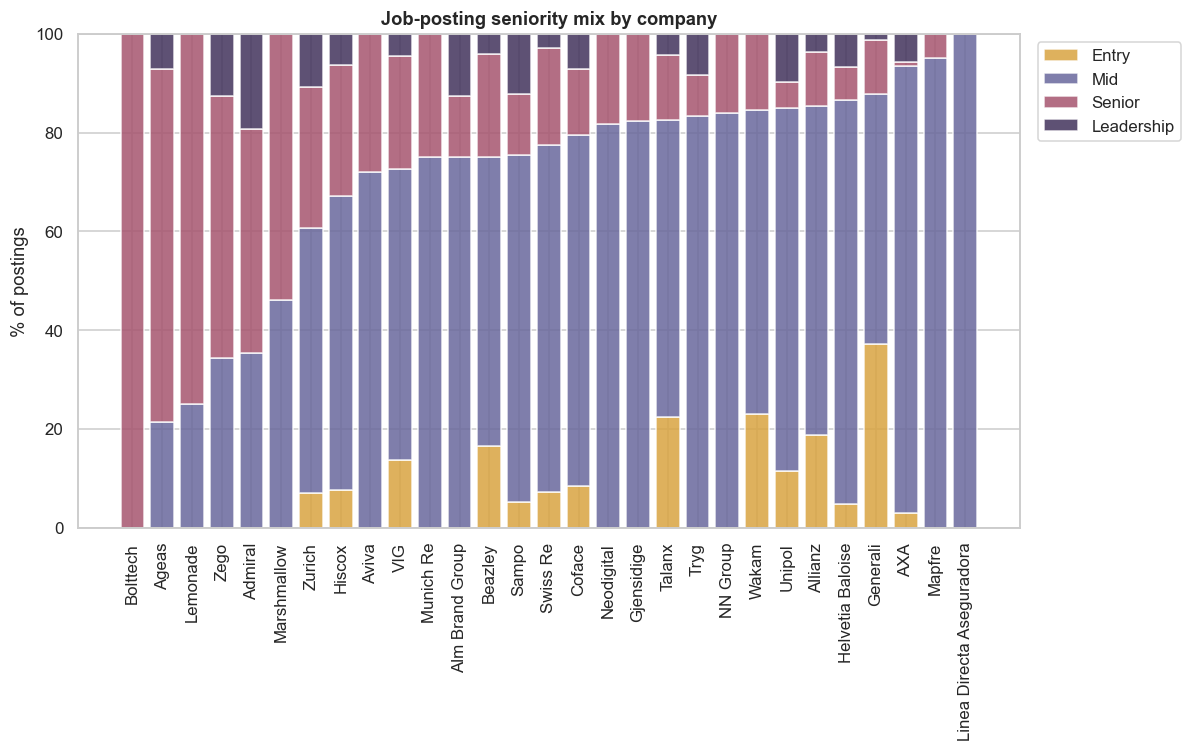

In [32]:
fig, ax = plt.subplots(figsize=(11, 7))
bottom = np.zeros(len(company_pct))
for cat in SENIORITY_ORDER:
    ax.bar(company_pct.index, company_pct[cat], bottom=bottom, label=cat, color=SENIORITY_COLORS[cat], alpha=0.85)
    bottom += company_pct[cat].values
ax.set_ylabel("% of postings")
ax.set_title("Job-posting seniority mix by company")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=90)
plt.tight_layout(); save(fig, "seniority_by_company"); plt.show()

#### 12c. Tier-level seniority mix

Tier-level seniority mix (%):
seniority  Entry   Mid  Senior  Leadership
tier                                      
A           15.5  70.4    10.0         4.0
B            5.8  65.9    20.2         8.0
C            5.8  61.4    26.3         6.4
  saved -> 12c_seniority_by_tier.png


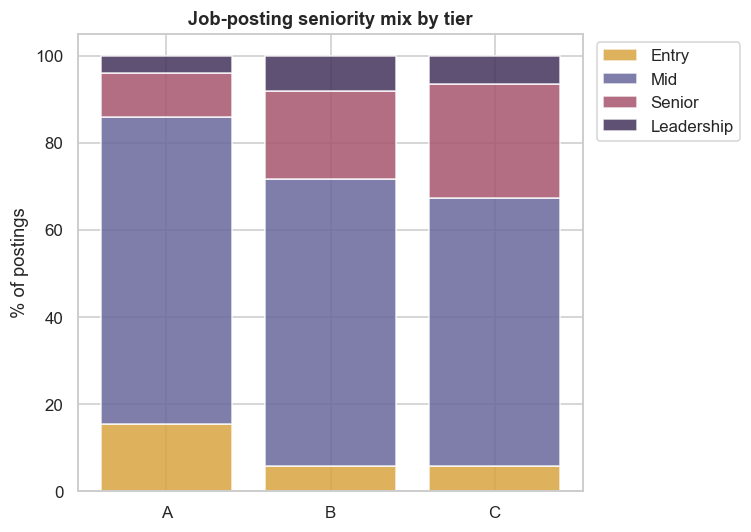

In [33]:
tier_mix = (sen.dropna(subset=["tier"]).groupby(["tier","seniority"]).size().unstack(fill_value=0)
            .reindex(columns=SENIORITY_ORDER, fill_value=0).reindex(["A","B","C"]))
tier_pct = tier_mix.div(tier_mix.sum(axis=1), axis=0) * 100
print("Tier-level seniority mix (%):")
print(tier_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(3)
for cat in SENIORITY_ORDER:
    ax.bar(tier_pct.index, tier_pct[cat], bottom=bottom, label=cat, color=SENIORITY_COLORS[cat], alpha=0.85)
    bottom += tier_pct[cat].values
ax.set_ylabel("% of postings")
ax.set_title("Job-posting seniority mix by tier")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); save(fig, "12c_seniority_by_tier"); plt.show()


#### 12d. Automation depth vs hiring seniority

The actual question behind this exploration: do companies with higher report-side automation depth
hire proportionally more senior roles? Uses `m` directly (no CSV round-trip). Correlation is reported
**both with and without low-volume companies**, in the same spirit as the SFCR sensitivity check in
section 11 — so a noisy 2-posting company can't quietly drive the headline number.

Merged 29 companies (of 29 with seniority data, 29 in the combined table)
Full sample: corr(automation depth, % senior+leadership) = +0.130 (p=0.503, n=29)
Excl. n<5: corr(automation depth, % senior+leadership) = +0.079 (p=0.696, n=27)
  saved -> 12d_role_evolution_vs_seniority.png


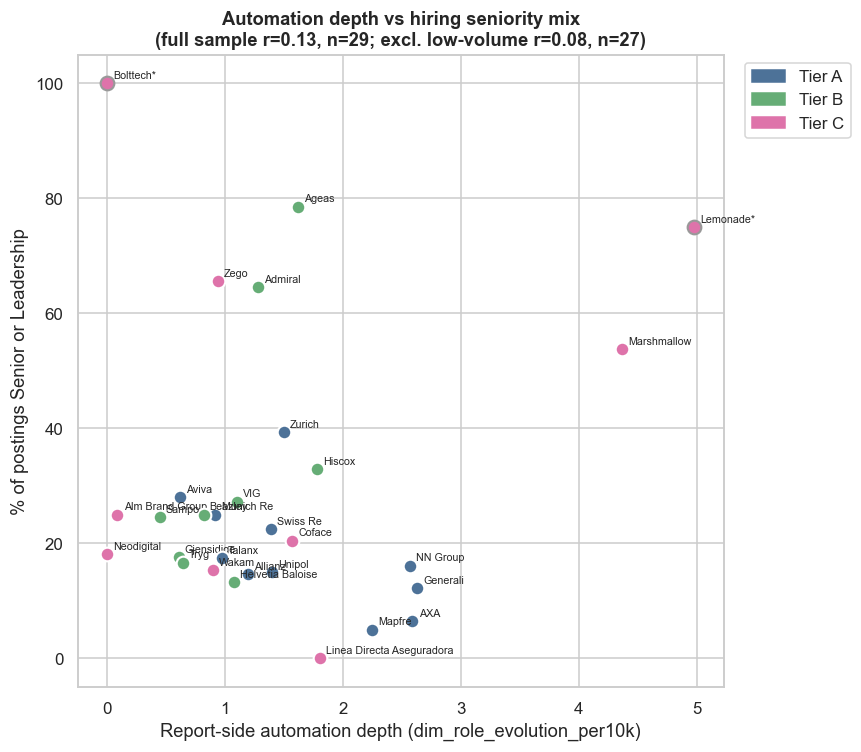


Same small-n caveat as the rest of the combine analysis: n=29 is exploratory, not confirmatory.
Companies marked * have fewer than 5 postings -- their seniority mix is noisy.


In [34]:
sen_merged = company_pct.reset_index().merge(
    m[["company","dim_role_evolution_per10k","z_report_share"]], on="company", how="inner"
)
sen_merged["tier"] = sen_merged["company"].map(m.set_index("company")["tier"])
print(f"Merged {len(sen_merged)} companies (of {len(company_pct)} with seniority data, {len(m)} in the combined table)")

def seniority_corr(data, label):
    r, pv = stats.pearsonr(data["dim_role_evolution_per10k"], data["senior_leadership_pct"])
    print(f"{label}: corr(automation depth, % senior+leadership) = {r:+.3f} (p={pv:.3f}, n={len(data)})")
    return r, pv

r_full, pv_full = seniority_corr(sen_merged, "Full sample")
sen_excl = sen_merged[~sen_merged["low_volume_flag"]]
r_excl, pv_excl = seniority_corr(sen_excl, f"Excl. n<{MIN_POSTINGS_SENIORITY}")

fig, ax = plt.subplots(figsize=(8, 7))
for _, row in sen_merged.iterrows():
    marker_edge = "#999999" if row["low_volume_flag"] else "white"
    ax.scatter(row["dim_role_evolution_per10k"], row["senior_leadership_pct"], s=80,
               color=TIER_COLORS.get(row["tier"], "#888"), zorder=3, edgecolor=marker_edge, linewidth=1.4)
    label = f"{row['company']}*" if row["low_volume_flag"] else row["company"]
    ax.annotate(label, (row["dim_role_evolution_per10k"], row["senior_leadership_pct"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Report-side automation depth (dim_role_evolution_per10k)")
ax.set_ylabel("% of postings Senior or Leadership")
ax.set_title(f"Automation depth vs hiring seniority mix\n(full sample r={r_full:.2f}, n={len(sen_merged)}; "
             f"excl. low-volume r={r_excl:.2f}, n={len(sen_excl)})")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=f"Tier {t}") for t, c in TIER_COLORS.items()],
          loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); save(fig, "12d_role_evolution_vs_seniority"); plt.show()

print(f"\nSame small-n caveat as the rest of the combine analysis: n={len(sen_merged)} is exploratory, not confirmatory.")
print(f"Companies marked * have fewer than {MIN_POSTINGS_SENIORITY} postings -- their seniority mix is noisy.")


Correlation of each seniority level's % with role evolution (full sample):
     level      r     p
     Entry -0.002 0.993
       Mid -0.136 0.480
    Senior  0.188 0.329
Leadership -0.261 0.171
  saved -> 12d_seniority_vs_role_evolution_grid.png


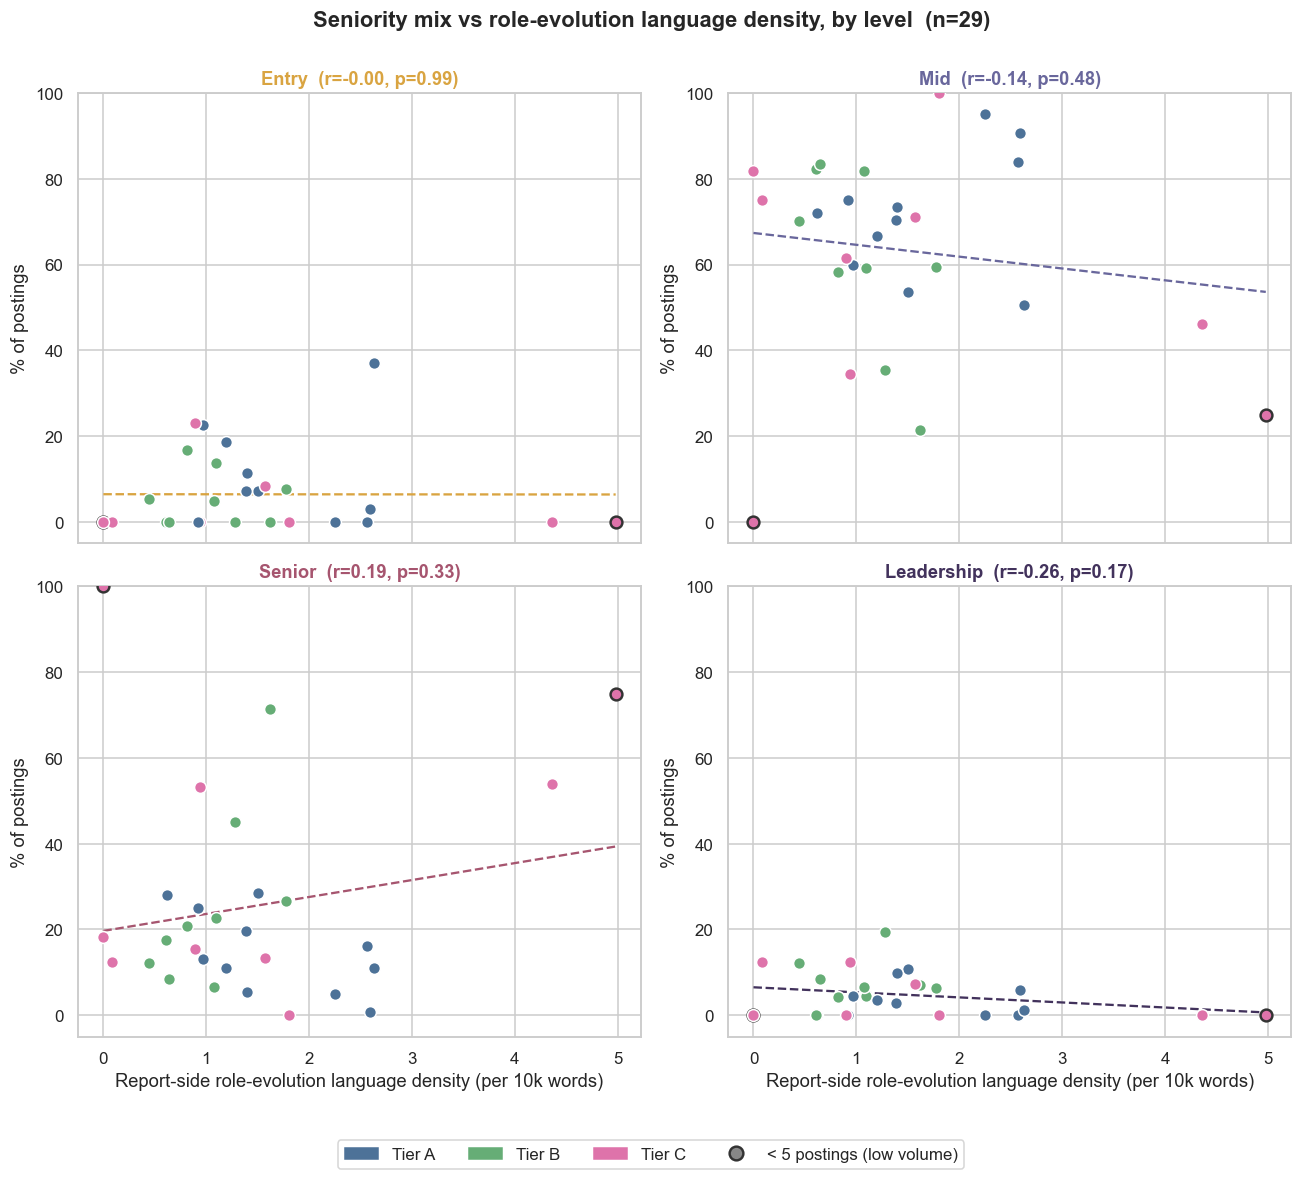


Same small-n caveat applies -- read these as exploratory directional signals, not confirmed effects, n=29.


In [35]:
from matplotlib.lines import Line2D

SENIORITY_MIN_POSTINGS = 5   # deliberately looser than the main track's 10 (see §3.8)
sen_merged = sen_merged.copy()
sen_merged["low_volume_flag"] = sen_merged["n_postings"] < SENIORITY_MIN_POSTINGS

print("Correlation of each seniority level's % with role evolution (full sample):")
corr_rows = []
for level in SENIORITY_ORDER:
    r, pv = stats.pearsonr(sen_merged["dim_role_evolution_per10k"], sen_merged[level])
    corr_rows.append({"level": level, "r": round(r, 3), "p": round(pv, 3)})
print(pd.DataFrame(corr_rows).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
for ax, level in zip(axes.flat, SENIORITY_ORDER):
    for _, row in sen_merged.iterrows():
        lv = row["low_volume_flag"]
        ax.scatter(row["dim_role_evolution_per10k"], row[level], s=60,
                   color=TIER_COLORS.get(row["tier"], "#888"), zorder=3,
                   edgecolor="#333333" if lv else "white",
                   linewidth=1.6 if lv else 1.0)
    r, pv = stats.pearsonr(sen_merged["dim_role_evolution_per10k"], sen_merged[level])
    slope, intercept = np.polyfit(sen_merged["dim_role_evolution_per10k"], sen_merged[level], 1)
    xs = np.linspace(sen_merged["dim_role_evolution_per10k"].min(),
                     sen_merged["dim_role_evolution_per10k"].max(), 50)
    ax.plot(xs, slope * xs + intercept, "--", color=SENIORITY_COLORS[level], lw=1.5, zorder=2)
    ax.set_title(f"{level}  (r={r:.2f}, p={pv:.2f})", color=SENIORITY_COLORS[level])
    ax.set_ylabel("% of postings")
    ax.set_ylim(-5, 100)
for ax in axes[1]:
    ax.set_xlabel("Report-side role-evolution language density (per 10k words)")

fig.suptitle(f"Seniority mix vs role-evolution language density, by level  (n={len(sen_merged)})",
             fontweight="bold", y=1.00)
handles = ([Patch(color=c, label=f"Tier {t}") for t, c in TIER_COLORS.items()]
           + [Line2D([0], [0], marker="o", color="none", markerfacecolor="#888",
                     markeredgecolor="#333333", markeredgewidth=1.6, markersize=9,
                     label=f"< {SENIORITY_MIN_POSTINGS} postings (low volume)")])
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4)
plt.tight_layout()
save(fig, "12d_seniority_vs_role_evolution_grid"); plt.show()

print(f"\nSame small-n caveat applies -- read these as exploratory directional signals, not confirmed effects, n={len(sen_merged)}.")